In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
# Install Hugging Face
!pip install transformers datasets seqeval -q

from transformers import (
    BertTokenizerFast,
    BertForTokenClassification
)
from transformers.optimization import get_linear_schedule_with_warmup
from datasets import load_dataset
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score

print("Libraries loaded!")

PyTorch: 2.10.0+cu128
Device: cuda
Libraries loaded!


In [3]:
"""
Names Entity Recognition(NEM) is used to identify named entities in text

Some entity types are:
  • PER (Person): Names of people
  • ORG (Organization): Companies, agencies, institutions
  • LOC (Location): Cities, countries, addresses
  • MISC (Miscellaneous): Nationalities, events, products
  • DATE: Dates and times
  • MONEY: Monetary values

"""

'\nNames Entity Recognition(NEM) is used to identify named entities in text\n\nSome entity types are:\n  • PER (Person): Names of people\n  • ORG (Organization): Companies, agencies, institutions\n  • LOC (Location): Cities, countries, addresses\n  • MISC (Miscellaneous): Nationalities, events, products\n  • DATE: Dates and times\n  • MONEY: Monetary values\n\n'

Bio Tagging Scheme

In [5]:
"""
NEM Is formulated as TOKEN-LEVEL classification. Each token gets a tag using the BIO Scheme:

  B = Beginning of entity
  I = Inside entity
  O = Outside (not an entity)

Example: "Steve Jobs founded Apple"

Tokens: ["Steve", "Jobs", "founded", "Apple"]
Tags: ["B-PER", "I-PER", "O", "B-ORG"]
"""

'\nNEM Is formulated as TOKEN-LEVEL classification. Each token gets a tag using the BIO Scheme:\n\n  B = Beginning of entity\n  I = Inside entity\n  O = Outside (not an entity)\n\nExample: "Steve Jobs founded Apple"\n\nTokens: ["Steve", "Jobs", "founded", "Apple"]\nTags: ["B-PER", "I-PER", "O", "B-ORG"]\n'

In [6]:
# Visualize BIO tagging
example_sentence = ["Steve", "Jobs", "founded", "Apple", "in", "California", "in", "1976", "."]
example_tags = ["B-PER", "I-PER", "O", "B-ORG", "O", "B-LOC", "O", "O", "O"]

print("BIO Tagging Example:")
print("="*50)
print(f"{'Token':<12} {'Tag':<10} {'Meaning'}")
print("-"*50)
for token, tag in zip(example_sentence, example_tags):
    if tag.startswith('B-'):
        meaning = f"Beginning of {tag[2:]}"
    elif tag.startswith('I-'):
        meaning = f"Inside {tag[2:]}"
    else:
        meaning = "Not an entity"
    print(f"{token:<12} {tag:<10} {meaning}")

BIO Tagging Example:
Token        Tag        Meaning
--------------------------------------------------
Steve        B-PER      Beginning of PER
Jobs         I-PER      Inside PER
founded      O          Not an entity
Apple        B-ORG      Beginning of ORG
in           O          Not an entity
California   B-LOC      Beginning of LOC
in           O          Not an entity
1976         O          Not an entity
.            O          Not an entity


In [7]:
def load_conll(filepath):
    sentences, labels = [], []
    tokens, tags = [], []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line == '' or line.startswith('-DOCSTART-'):
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
            else:
                parts = line.split()
                tokens.append(parts[0])
                tags.append(parts[-1])
        if tokens:
            sentences.append(tokens)
            labels.append(tags)
    return sentences, labels

In [8]:
import os

# Assuming the CoNLL-2003 dataset files are now in the current directory:
# eng.train, eng.testa, eng.testb

train_sentences, train_labels = load_conll('eng.train')
val_sentences, val_labels     = load_conll('eng.testa')
test_sentences, test_labels   = load_conll('eng.testb')

print(f"Train: {len(train_sentences)} sentences")
print(f"Val:   {len(val_sentences)} sentences")
print(f"Test:  {len(test_sentences)} sentences")

Train: 14041 sentences
Val:   3250 sentences
Test:  3453 sentences


In [9]:
# Check features
all_labels = [label for sublist in train_labels for label in sublist] + \
             [label for sublist in val_labels for label in sublist]
label_names = sorted(list(set(all_labels)))

print("\nAvailable Labels (Features):")
print(label_names)


Available Labels (Features):
['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [10]:
print("features")
print(label_names)

features
['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [11]:
num_labels = len(label_names)

print(f"\nNER Labels: ({num_labels}):")
for i, name in enumerate(label_names):
  print(f"  {i}: {name}")


#creating mappings
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for i, label in enumerate(label_names)}


NER Labels: (9):
  0: B-LOC
  1: B-MISC
  2: B-ORG
  3: B-PER
  4: I-LOC
  5: I-MISC
  6: I-ORG
  7: I-PER
  8: O


In [12]:
print("Sample sentences")

for i in range(3):
  tokens = train_sentences[i]
  tags = train_labels[i]

  print(f"\n Sentence {i + 1}:")
  print(f" Tokens: {''.join(tokens)}")
  print(f" Tags: {''.join(tags)}")

  #show entities
  entities = []
  for token, tag in zip(tokens, tags):
    if tag != 'O':
      entities.append(f"{token} ({tag})")

  if entities:
    print(f" Entities: {', '.join(entities)}")

Sample sentences

 Sentence 1:
 Tokens: EUrejectsGermancalltoboycottBritishlamb.
 Tags: B-ORGOB-MISCOOOB-MISCOO
 Entities: EU (B-ORG), German (B-MISC), British (B-MISC)

 Sentence 2:
 Tokens: PeterBlackburn
 Tags: B-PERI-PER
 Entities: Peter (B-PER), Blackburn (I-PER)

 Sentence 3:
 Tokens: BRUSSELS1996-08-22
 Tags: B-LOCO
 Entities: BRUSSELS (B-LOC)


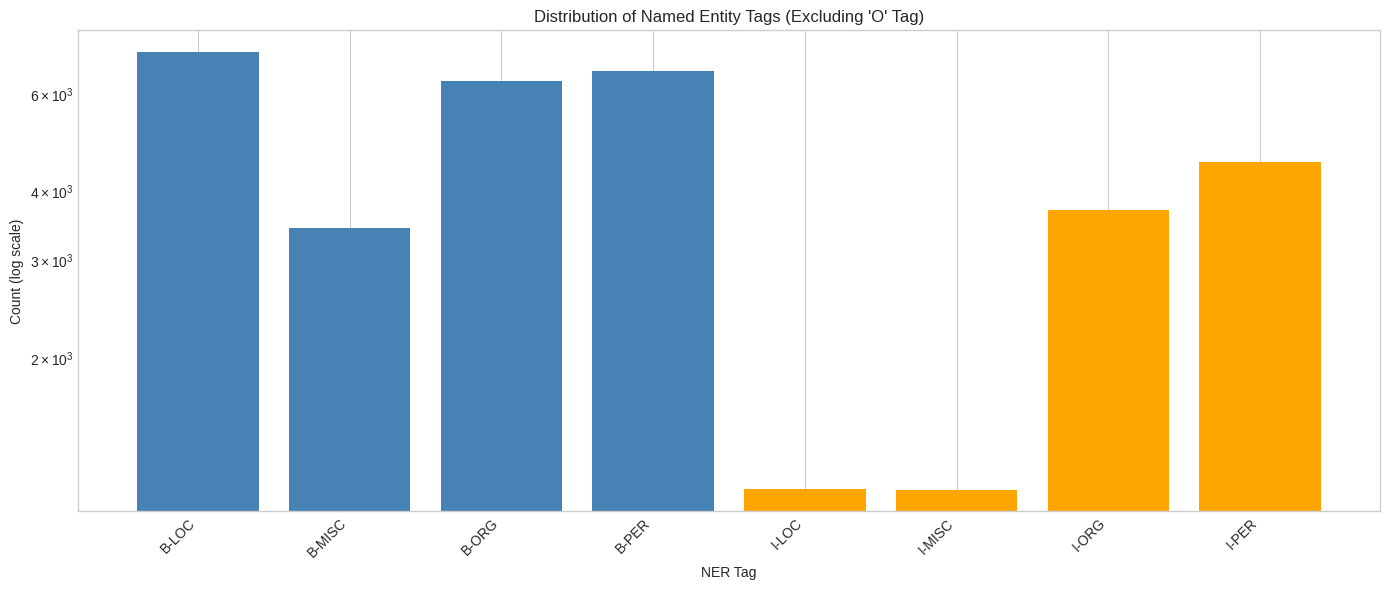

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# Collecting all tags
all_tags = [tag for sublist in train_labels for tag in sublist]

# Filtering out 'O' (Outside) tags for better entity distribution visualization
filtered_tags = [tag for tag in all_tags if tag != 'O']

tag_counts = Counter(filtered_tags)

# Only include tags that are present in filtered_tags
filtered_label_names = [name for name in label_names if name != 'O']
counts = [tag_counts.get(name, 0) for name in filtered_label_names]

plt.figure(figsize=(14, 6))
colors = ['steelblue' if name.startswith('B-') else 'orange' for name in filtered_label_names] # Differentiate B- and I-tags if desired

plt.bar(filtered_label_names, counts, color=colors)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count (log scale)")
plt.xlabel('NER Tag')
plt.title("Distribution of Named Entity Tags (Excluding 'O' Tag)")
plt.tight_layout()
plt.show()

Tokenization

In [14]:
"""
Problem: BERT uses WordPiece tokenization, which splits words into subwords.

Example:
  Original: ["California", "is", "beautiful"]
  Labels:   [B-LOC,        O,    O]

  After WordPiece:
  Tokens: ["Cali", "##fornia", "is", "beautiful"]
  Labels: [B-LOC,  ???,        O,    O]

Solution: Align labels with subword tokens.

Strategy:
  • First subword: Original label
  • Continuation subwords (##): -100 (ignore in loss)

  OR

  • First subword: Original label (B-LOC)
  • Continuation: Same label or I-label (I-LOC)

We'll use: -100 for continuation (standard approach)

"""

'\nProblem: BERT uses WordPiece tokenization, which splits words into subwords.\n\nExample:\n  Original: ["California", "is", "beautiful"]\n  Labels:   [B-LOC,        O,    O]\n  \n  After WordPiece:\n  Tokens: ["Cali", "##fornia", "is", "beautiful"]\n  Labels: [B-LOC,  ???,        O,    O]\n\nSolution: Align labels with subword tokens.\n  \nStrategy:\n  • First subword: Original label\n  • Continuation subwords (##): -100 (ignore in loss)\n  \n  OR\n  \n  • First subword: Original label (B-LOC)\n  • Continuation: Same label or I-label (I-LOC)\n  \nWe\'ll use: -100 for continuation (standard approach)\n\n'

In [15]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-cased')

print(f"Vocab size: {tokenizer.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 28996


In [16]:
#demo
sample_tokens = ["Steve", 'Jobs', 'founded', 'Apple', 'in', 'California', 'in', '1976', '.']
sample_labels = ['B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC', 'O', 'O', 'O']

encoding = tokenizer(
    sample_tokens,
    is_split_into_words=True,
    return_offsets_mapping=True,
    padding=False,
    truncation=True,
)

print(f"Original tokens: {sample_tokens}")
print(f"Originla labels: {sample_labels}")
print(f"Tokens: {encoding['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(encoding['input_ids'])}")

Original tokens: ['Steve', 'Jobs', 'founded', 'Apple', 'in', 'California', 'in', '1976', '.']
Originla labels: ['B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC', 'O', 'O', 'O']
Tokens: [101, 3036, 18235, 1116, 1771, 7302, 1107, 1756, 1107, 2402, 119, 102]
Decoded tokens: ['[CLS]', 'Steve', 'Job', '##s', 'founded', 'Apple', 'in', 'California', 'in', '1976', '.', '[SEP]']


In [17]:
#the label alignment function
def align_labels(word_ids, labels):
  """
  Align labels with subword tokens.Labels

  Args:
      word_ids: list of word ids
      labels: list of labels
  Returns:
      aligned_labels: list of aligned labels

  """

  aligned_labels = []
  previous_word_idx = None

  for word_idx in word_ids:
    if word_idx is None:
      aligned_labels.append(-100)
    elif word_idx != previous_word_idx:
      aligned_labels.append(labels[word_idx])
    else:
      aligned_labels.append(-100)

    previous_word_idx = word_idx

  return aligned_labels

sample_ids = [label2id[l] for l in sample_labels]
aligned = align_labels(encoding.word_ids(), sample_ids)

print(f"Original labels: {sample_labels}")
print(f"Aligned labels: {aligned}")

Original labels: ['B-PER', 'I-PER', 'O', 'B-ORG', 'O', 'B-LOC', 'O', 'O', 'O']
Aligned labels: [-100, 3, 7, -100, 8, 2, 8, 0, 8, 8, 8, -100]


In [18]:
tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'])
for tok, word_id, label in zip(tokens, encoding.word_ids(), aligned):
    label_name = label_names[label] if label != -100 else 'IGNORE'
    print(f"{tok:<15} word_id={word_id}  →  {label_name}")

[CLS]           word_id=None  →  IGNORE
Steve           word_id=0  →  B-PER
Job             word_id=1  →  I-PER
##s             word_id=1  →  IGNORE
founded         word_id=2  →  O
Apple           word_id=3  →  B-ORG
in              word_id=4  →  O
California      word_id=5  →  B-LOC
in              word_id=6  →  O
1976            word_id=7  →  O
.               word_id=8  →  O
[SEP]           word_id=None  →  IGNORE


Preprocessing

In [19]:
MAX_LEN = 128

# Import Dataset from the datasets library
from datasets import Dataset, DatasetDict

def tokenize_and_align(examples):
  tokenized = tokenizer(
      examples['tokens'],
      is_split_into_words=True,
      truncation=True,
      padding='max_length',
      max_length=MAX_LEN,
      return_offsets_mapping=True,
  )

  all_labels = []
  for i, labels in enumerate(examples['ner_tags']):
    word_ids = tokenized.word_ids(batch_index=i)
    # Convert string labels to their integer IDs using label2id
    aligned = align_labels(word_ids, [label2id[l] for l in labels])
    all_labels.append(aligned)

  tokenized['labels'] = all_labels # Corrected assignment: to tokenized dictionary
  return tokenized

# train_labels, val_labels, test_labels, and label2id are defined from previous cells.
raw_datasets = {
    'train': Dataset.from_dict({
        'tokens': train_sentences,
        'ner_tags': train_labels
    }),
    'validation': Dataset.from_dict({
        'tokens': val_sentences,
        'ner_tags': val_labels
    }),
    'test': Dataset.from_dict({
        'tokens': test_sentences,
        'ner_tags': test_labels
    })
}

# Applying it to all splits of the dataset
tokenized_dataset = DatasetDict({
    'train': raw_datasets['train'].map(
        tokenize_and_align,
        batched=True,
        remove_columns=raw_datasets['train'].column_names,
    ),
    'validation': raw_datasets['validation'].map(
        tokenize_and_align,
        batched=True,
        remove_columns=raw_datasets['validation'].column_names,
    ),
    'test': raw_datasets['test'].map(
        tokenize_and_align,
        batched=True,
        remove_columns=raw_datasets['test'].column_names,
    )
})
print(tokenized_dataset)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 3453
    })
})


In [20]:
# Set format for PyTorch
tokenized_dataset.set_format('torch')

# Check a sample
sample = tokenized_dataset['train'][0]
print(f"Sample keys: {sample.keys()}")
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Labels shape: {sample['labels'].shape}")

Sample keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'])
Input IDs shape: torch.Size([128])
Labels shape: torch.Size([128])


In [21]:
BATCH_SIZE = 16

train_loader = DataLoader(
    tokenized_dataset['train'],
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    tokenized_dataset['validation'],
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    tokenized_dataset['test'],
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 878
Val batches: 204
Test batches: 216


In [22]:
#Loading pre-trained BERT
model = BertForTokenClassification.from_pretrained(
    'bert-base-cased',
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"No. of labels: {num_labels}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Total parameters: 107726601
Trainable parameters: 107726601
No. of labels: 9


In [39]:
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

#scheduler
EPOCHS = 5
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=int(0.1 * total_steps),
)

print(f"Total steps: {total_steps}")
print(f"Warmup steps: {int(0.1 * total_steps)}")

Total steps: 4390
Warmup steps: 439


In [40]:
#training function
def train_epoch(model, loader, optimizer, scheduler):
  model.train()
  total_loss = 0

  for batch in loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    total_loss += loss.item()

  return total_loss / len(loader)

print('Training function definec')

Training function definec


In [41]:
# Evaluation function with entity-level metrics
def evaluate(model, loader):
  model.eval()
  total_loss = 0

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for batch in loader:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['labels'].to(device)

      outputs = model(
          input_ids = input_ids,
          attention_mask = attention_mask,
          labels = labels
      )

      total_loss += outputs.loss.item()

      pred = torch.argmax(outputs.logits, dim=-1)

      #converting to lists
      for p, l in zip(pred.cpu().numpy(), labels.cpu().numpy()):
        pred_tags = []
        true_tags = []
        for p_token, l_token in zip(p, l):
          if l_token != -100:
            pred_tags.append(id2label[p_token])
            true_tags.append(id2label[l_token])
        all_preds.append(pred_tags)
        all_labels.append(true_tags)
  f1 = seq_f1_score(all_labels, all_preds)

  return total_loss / len(loader), f1, all_preds, all_labels

print('Evaluation function defined')

Evaluation function defined


In [42]:
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0

print(f"Fine-tuning BERT for NER. . .")

for epoch in range(EPOCHS):
  train_loss = train_epoch(model, train_loader, optimizer, scheduler)
  val_loss, val_f1, _, _ = evaluate(model, val_loader)

  history['train_loss'].append(train_loss)
  history['val_loss'].append(val_loss)
  history['val_f1'].append(val_f1)

  #save the best model
  if val_f1 > best_f1:
    best_f1 = val_f1
    torch.save(model.state_dict(), 'best_model.pt')
    marker = "Saved"

  else:
    marker = ''

  print(f"Epoch: {epoch+1}/{EPOCHS} | "
        f"Train_loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f}")

print(f"\Best validation F1: {best_f1:.4f}")

Fine-tuning BERT for NER. . .
Epoch: 1/5 | Train_loss: 0.0445 | Val loss: 0.0429 | Val F1: 0.9319
Epoch: 2/5 | Train_loss: 0.0344 | Val loss: 0.0429 | Val F1: 0.9319
Epoch: 3/5 | Train_loss: 0.0343 | Val loss: 0.0429 | Val F1: 0.9319
Epoch: 4/5 | Train_loss: 0.0341 | Val loss: 0.0429 | Val F1: 0.9319
Epoch: 5/5 | Train_loss: 0.0347 | Val loss: 0.0429 | Val F1: 0.9319
\Best validation F1: 0.9319


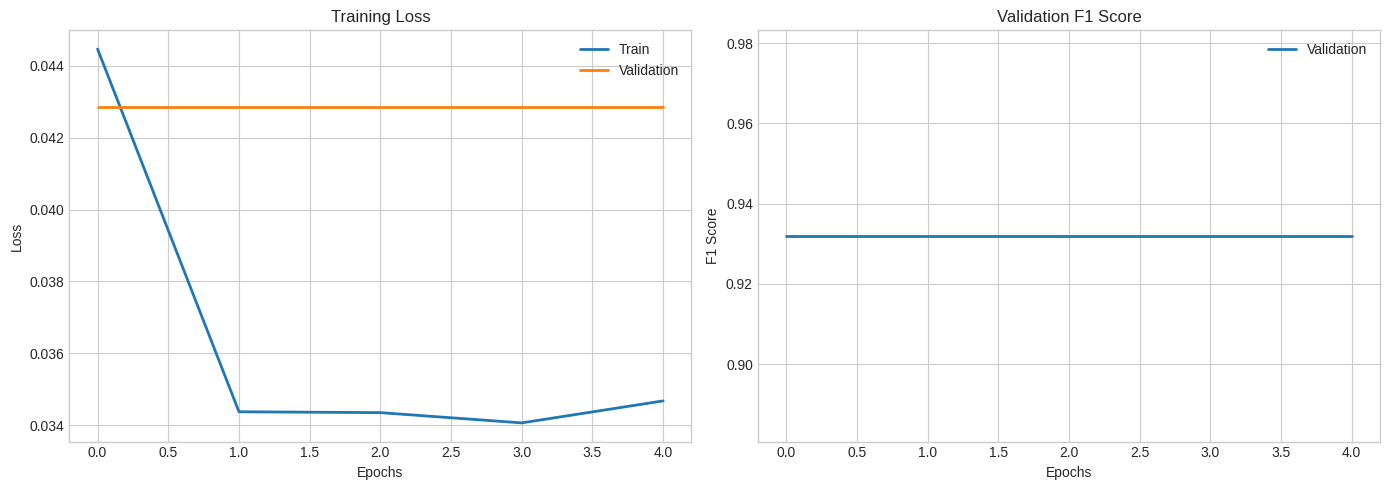

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True)

#F1 score
axes[1].plot(history['val_f1'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title("Validation F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluating on the test set

In [46]:
model.load_state_dict(torch.load('best_model.pt'))
print("Loaded the best model")

Loaded the best model


In [47]:
test_loss, test_f1, test_preds, test_labels = evaluate(model, test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test F1: {test_f1:.4f}")

Test loss: 0.1078
Test F1: 0.8954


In [50]:
print('Classification report')
print(seq_classification_report(test_labels, test_preds))

Classification report
              precision    recall  f1-score   support

         LOC       0.92      0.92      0.92      1666
        MISC       0.72      0.79      0.75       702
         ORG       0.86      0.89      0.88      1661
         PER       0.96      0.95      0.96      1615

   micro avg       0.89      0.90      0.90      5644
   macro avg       0.86      0.89      0.88      5644
weighted avg       0.89      0.90      0.90      5644



Trying to predict on a custom set

In [54]:
def predict_ner(text, model, tokenizer):
  model.eval()

  # Split the input sentence into words for tokenization
  words_of_sentence = text.split()

  encoding = tokenizer(
      words_of_sentence, # Use the split words as input
      is_split_into_words=True,
      padding=True,
      truncation=True,
      return_tensors='pt',
      max_length=MAX_LEN
  )

  input_ids = encoding['input_ids'].to(device)
  attention_mask = encoding['attention_mask'].to(device)

  with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

  preds = torch.argmax(outputs.logits, dim=-1)[0].cpu().numpy()

  subword_word_ids = encoding.word_ids() # Maps subword token indices to original word indices

  # Initialize a list to hold the predicted tags for each original word, defaulting to 'O'
  final_word_predictions = ['O'] * len(words_of_sentence)
  previous_word_idx = None

  for i, word_idx in enumerate(subword_word_ids):
    # Process only tokens that correspond to an actual word (not special tokens like [CLS], [SEP])
    if word_idx is not None:
      # If this is the first subword of an original word (or if the previous subword belonged to a different original word),
      # assign the predicted tag for this subword to the corresponding original word.
      # This ensures each original word gets one tag, typically from its first subword.
      if word_idx != previous_word_idx:
        final_word_predictions[word_idx] = id2label[preds[i]] # Use id2label to get the string tag
      previous_word_idx = word_idx

  return list(zip(words_of_sentence, final_word_predictions))

print("prediction function ready")

prediction function ready


In [56]:
# Test on custom sentences
test_sentences = [
    "Steve Jobs founded Apple in California in 1976",
    "The European Union held talks in Brussels yesterday",
    "Elon Musk announced that Tesla will open a factory in Berlin",
    "The Olympics will be held in Paris in 2024",
    "Google and Microsoft are competing in the AI market",
]

print("NER Predictions on Custom Text")
print("="*60)

for sentence in test_sentences:
    print(f"\nText: {sentence}")
    print("-" * 50)

    predictions = predict_ner(sentence, model, tokenizer)

    # Display
    entities = []
    current_entity = []
    current_type = None

    for token, tag in predictions:
        if tag.startswith('B-'):
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
            current_entity = [token]
            current_type = tag[2:]
        elif tag.startswith('I-') and current_type:
            current_entity.append(token)
        else:
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
            current_entity = []
            current_type = None

    if current_entity:
        entities.append((' '.join(current_entity), current_type))

    if entities:
        for entity, etype in entities:
            print(f"  {entity} → {etype}")
    else:
        print("  No entities found")


NER Predictions on Custom Text

Text: Steve Jobs founded Apple in California in 1976
--------------------------------------------------
  Steve Jobs → PER
  Apple in California → ORG

Text: The European Union held talks in Brussels yesterday
--------------------------------------------------
  European Union → ORG
  Brussels → LOC

Text: Elon Musk announced that Tesla will open a factory in Berlin
--------------------------------------------------
  Elon Musk → ORG
  Tesla → ORG
  Berlin → LOC

Text: The Olympics will be held in Paris in 2024
--------------------------------------------------
  Olympics → MISC
  Paris → LOC

Text: Google and Microsoft are competing in the AI market
--------------------------------------------------
  Google → ORG
  Microsoft → ORG
  AI → MISC


Visualizing the entities

In [57]:
# HTML visualization
def visualize_ner_html(text, model, tokenizer):
    predictions = predict_ner(text, model, tokenizer)

    colors = {
        'PER': '#ff6b6b',
        'ORG': '#4ecdc4',
        'LOC': '#ffe66d',
        'MISC': '#a29bfe'
    }

    html = ""
    for token, tag in predictions:
        if tag == 'O':
            html += f"{token} "
        else:
            entity_type = tag[2:] if tag.startswith(('B-', 'I-')) else tag
            color = colors.get(entity_type, '#95a5a6')
            html += f'<span style="background-color:{color}; padding:2px 4px; border-radius:3px;">{token}<sub style="font-size:10px;">{entity_type}</sub></span> '

    return html

# Display using IPython
from IPython.display import HTML, display

print("NER Visualization")
print("="*60)
print("Legend: ")
display(HTML('<span style="background-color:#ff6b6b; padding:2px 4px;">PERSON</span> '
             '<span style="background-color:#4ecdc4; padding:2px 4px;">ORG</span> '
             '<span style="background-color:#ffe66d; padding:2px 4px;">LOC</span> '
             '<span style="background-color:#a29bfe; padding:2px 4px;">MISC</span>'))
print()

for sentence in test_sentences:
    html = visualize_ner_html(sentence, model, tokenizer)
    display(HTML(f'<p style="font-size:14px; line-height:2;">{html}</p>'))
    print()

NER Visualization
Legend: 


Interactive NER

In [59]:
# Interactive prediction
print("\nInteractive NER")
print("="*60)
print("Enter text to extract entities.")

text = input("\nText: ")

predictions = predict_ner(text, model, tokenizer)

print("\nEntities:")
print("-" * 40)

# Extract entities
entities = []
current_entity = []
current_type = None

for token, tag in predictions:
    if tag.startswith('B-'):
        if current_entity:
            entities.append((' '.join(current_entity), current_type))
        current_entity = [token]
        current_type = tag[2:]
    elif tag.startswith('I-') and current_type:
        current_entity.append(token)
    else:
        if current_entity:
            entities.append((' '.join(current_entity), current_type))
        current_entity = []
        current_type = None

if current_entity:
    entities.append((' '.join(current_entity), current_type))

if entities:
    for entity, etype in entities:
        print(f"  [{etype}] {entity}")
else:
    print("  No entities found")


Interactive NER
Enter text to extract entities.

Text: Harvard University  is located in Boston

Entities:
----------------------------------------
  [ORG] Harvard University
  [LOC] Boston


In [60]:
import os

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-55-ner'
os.makedirs(save_path, exist_ok=True)

# Save model and tokenizer
model.save_pretrained(f'{save_path}/bert_ner_conll')
tokenizer.save_pretrained(f'{save_path}/bert_ner_conll')

print(f"\nSaved to: {save_path}/bert_ner_conll")
print("\nTo load later:")
print("  model = BertForTokenClassification.from_pretrained('bert_ner_conll')")
print("  tokenizer = BertTokenizerFast.from_pretrained('bert_ner_conll')")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-55-ner/bert_ner_conll

To load later:
  model = BertForTokenClassification.from_pretrained('bert_ner_conll')
  tokenizer = BertTokenizerFast.from_pretrained('bert_ner_conll')
